In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv")

data = pd.DataFrame(df)

data

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


# Q1. Analysis of percentage joined of offer released.

In [25]:
Joined = list(data['Status'].value_counts())[0]
Not_Joined = list(data['Status'].value_counts())[1]

print(f"No of candidates joinged of offer released = {Joined}")
print(f"No of candidates not joinged of offer released = {Not_Joined}")

# ---------------------------------------------------------------------------------

Total_candidates = data.shape[0]

print(f"Total No of Candidiates = {Total_candidates}")

# ---------------------------------------------------------------------------------

joined_pct = (Joined / Total_candidates) * 100
not_joined_pct = (Not_Joined / Total_candidates) * 100

print(f"Percentage joined of offer release = {joined_pct : .2f} %")

No of candidates joinged of offer released = 7313
No of candidates not joinged of offer released = 1682
Total No of Candidiates = 8995
Percentage joined of offer release =  81.30 %


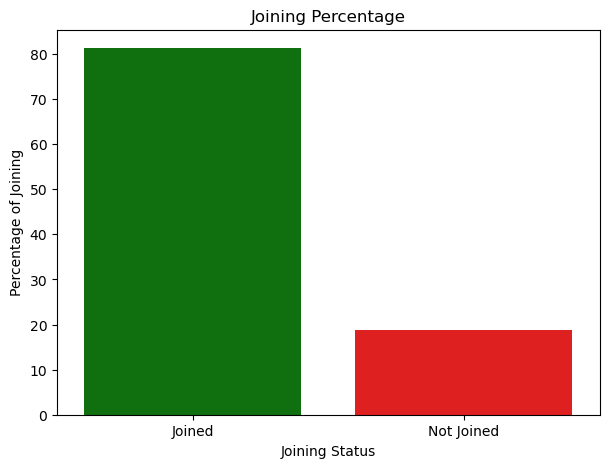

In [31]:
plt.figure(figsize = (7,5))

x = ['Joined', 'Not Joined']
y = [joined_pct, not_joined_pct]
colors = ['green', 'red']

sns.barplot(x=x, y=y, palette=colors)

plt.title("Joining Percentage")
plt.xlabel("Joining Status")
plt.ylabel("Percentage of Joining")

plt.show()

# Q2. What are the key drivers that influence the candidate joining/not joining a company?

In [49]:
useful_features_numerical = ['Notice_Period', 'Offered_CTC_hike_pct', 
            'Expected_CTC_hike_pct', 'CTC_diff_pct']

result = df.groupby('Status')[useful_features_numerical].mean().round(2)
print(result)

            Notice_Period  Offered_CTC_hike_pct  Expected_CTC_hike_pct  \
Status                                                                   
Joined              37.24                 41.13                  43.86   
Not Joined          48.19                 38.59                  43.88   

            CTC_diff_pct  
Status                    
Joined             -2.73  
Not Joined         -5.29  


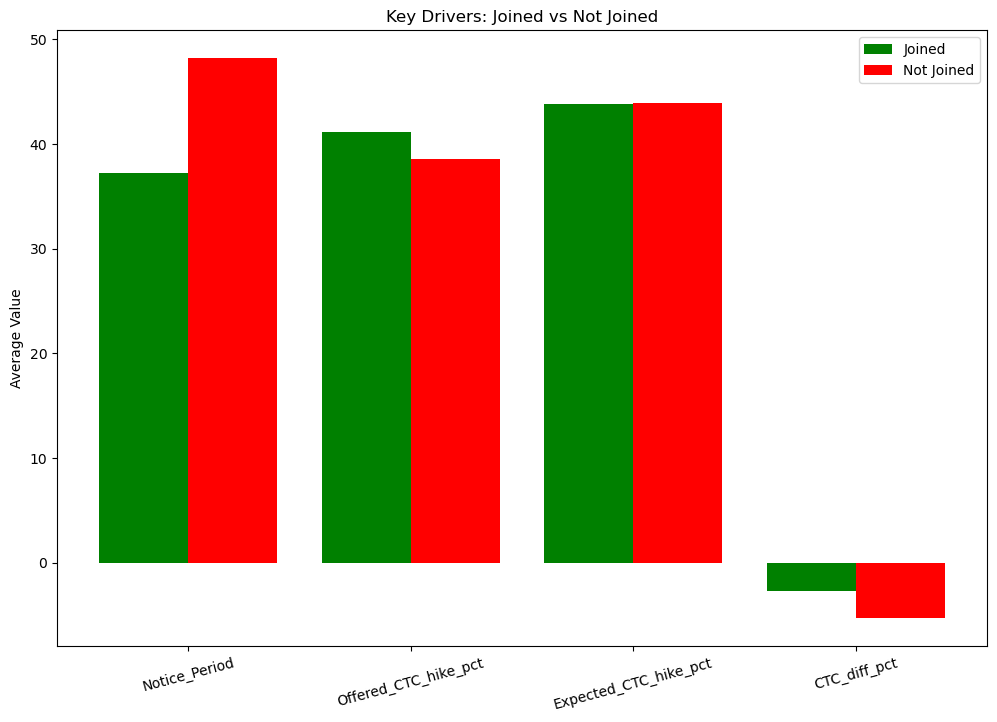

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))   

x = np.arange(len(useful_features))
width = 0.4

ax.bar(x - width/2, result.loc['Joined'],     width, label='Joined',     color='green')  
ax.bar(x + width/2, result.loc['Not Joined'], width, label='Not Joined', color='red')   

ax.set_title('Key Drivers: Joined vs Not Joined')  
ax.set_xticks(x)
ax.set_xticklabels(useful_features, rotation=15)   
ax.set_ylabel('Average Value')
ax.legend()

plt.show()

In [64]:
useful_features_categorical = list(data.select_dtypes(exclude='number').columns)

useful_features_categorical.remove('Date_of_Interview')
useful_features_categorical.remove('Status')

for col in useful_features_categorical:

    result_cat = df.groupby([col, 'Status']).size().unstack()

    print(result_cat)

Status        Joined  Not Joined
DOJ_Extended                    
No              3882         906
Yes             3431         776
Status        Joined  Not Joined
Offered_Band                    
E0               161          50
E1              4536        1042
E2              2188         516
E3               428          74
Status         Joined  Not Joined
Joining_Bonus                    
No               6977        1601
Yes               336          81
Status                     Joined  Not Joined
Candidate_relocate_actual                    
No                         6023.0      1682.0
Yes                        1290.0         NaN
Status  Joined  Not Joined
Gender                    
Female    1278         273
Male      6035        1409
Status             Joined  Not Joined
Candidate_Source                     
Agency               1960         625
Direct               3937         864
Employee Referral    1416         193
Status       Joined  Not Joined
Location_ID         

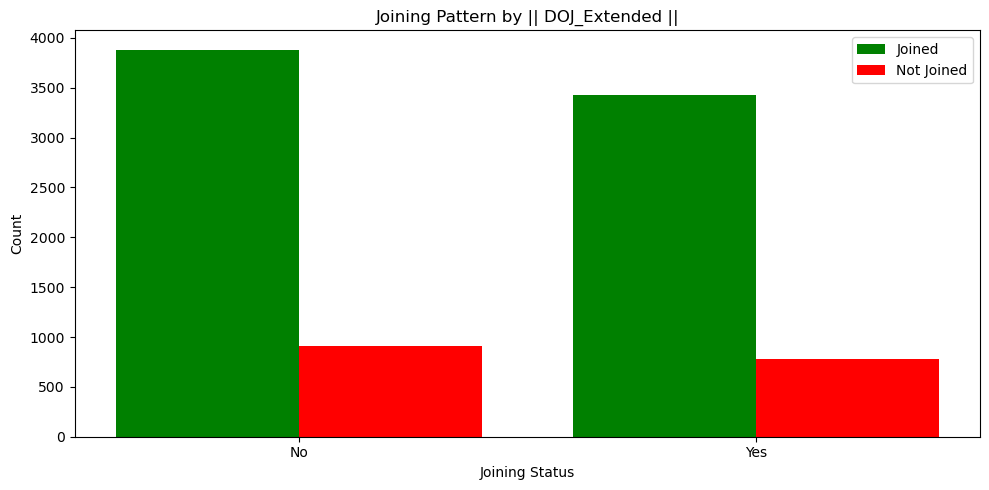

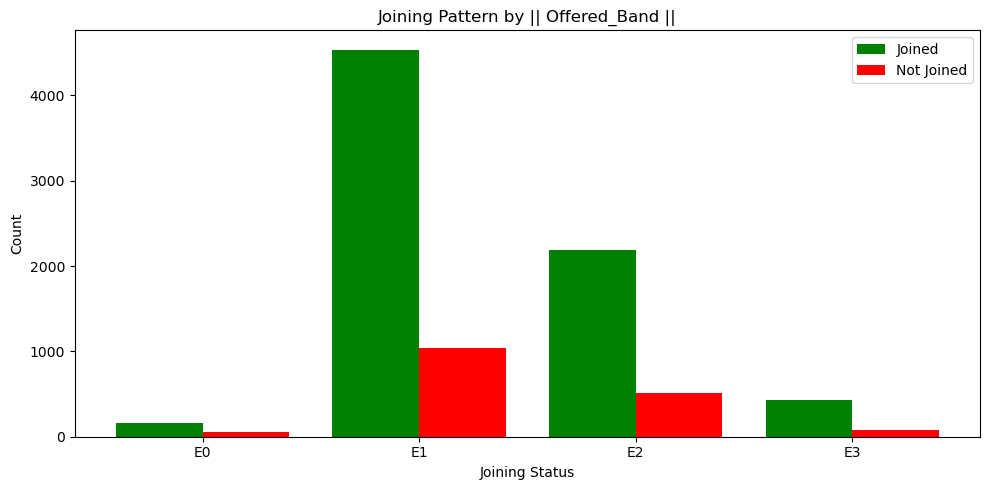

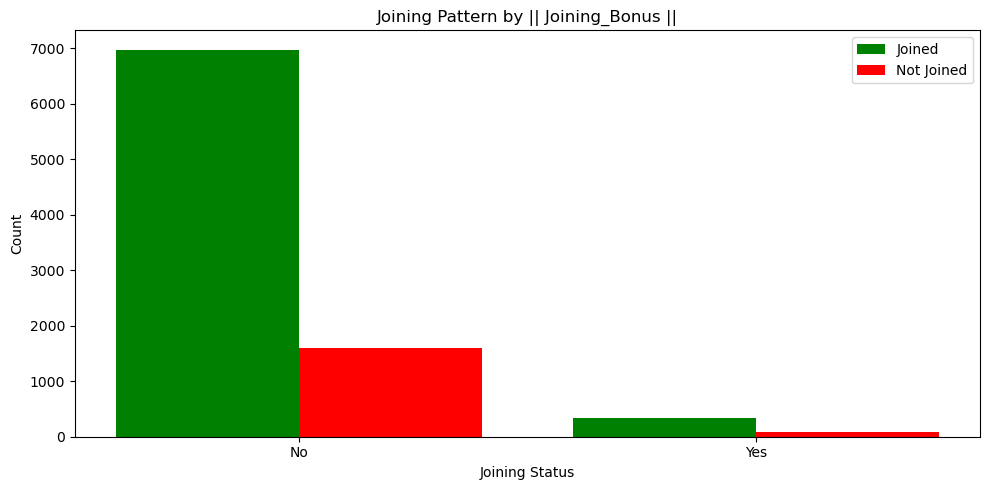

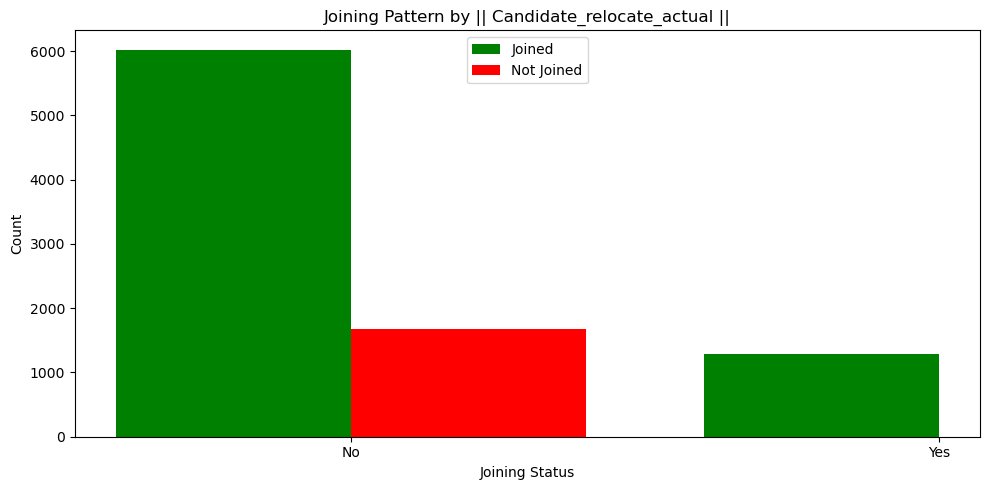

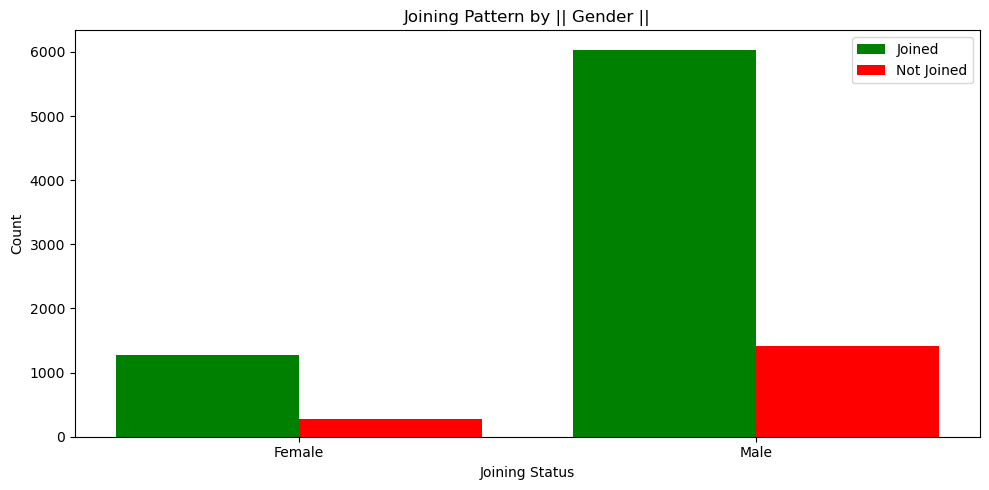

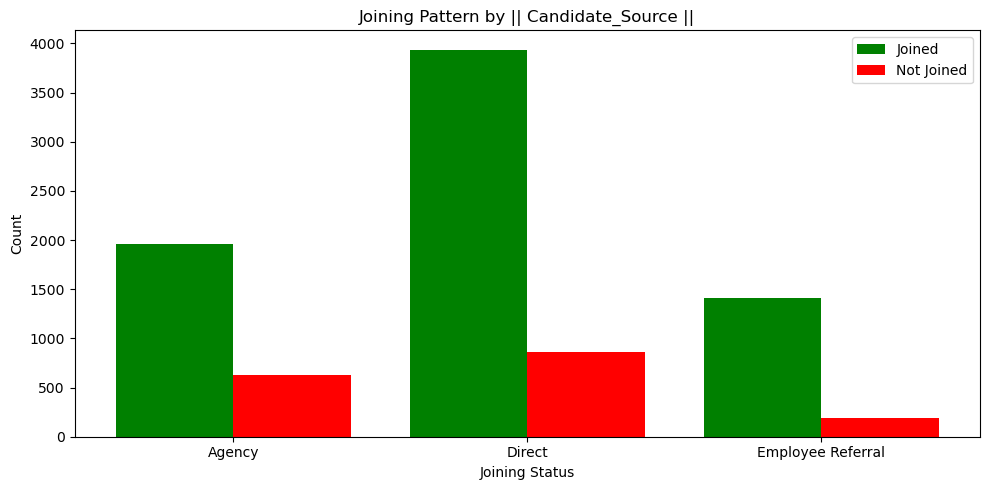

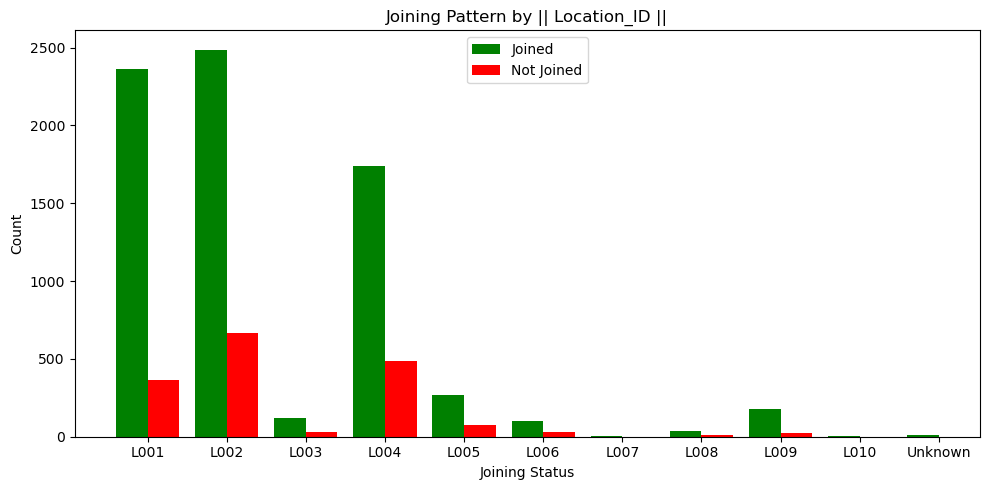

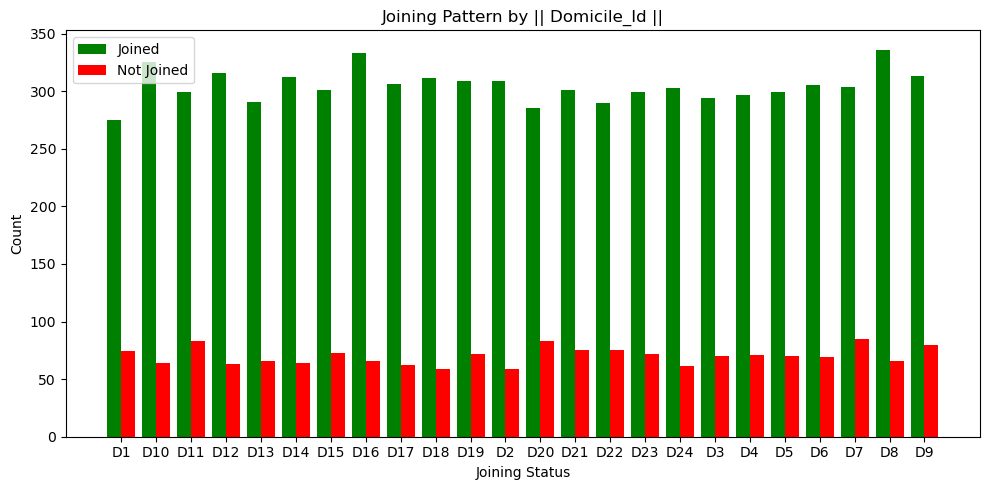

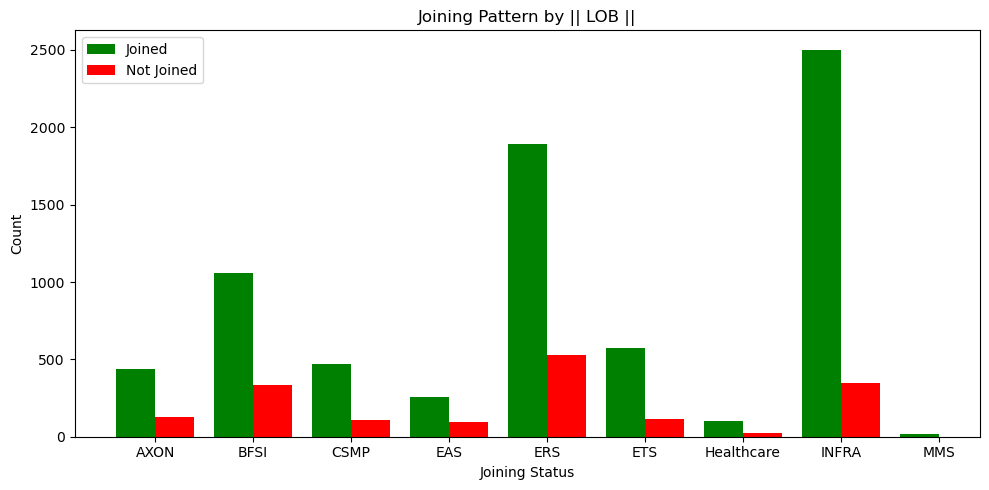

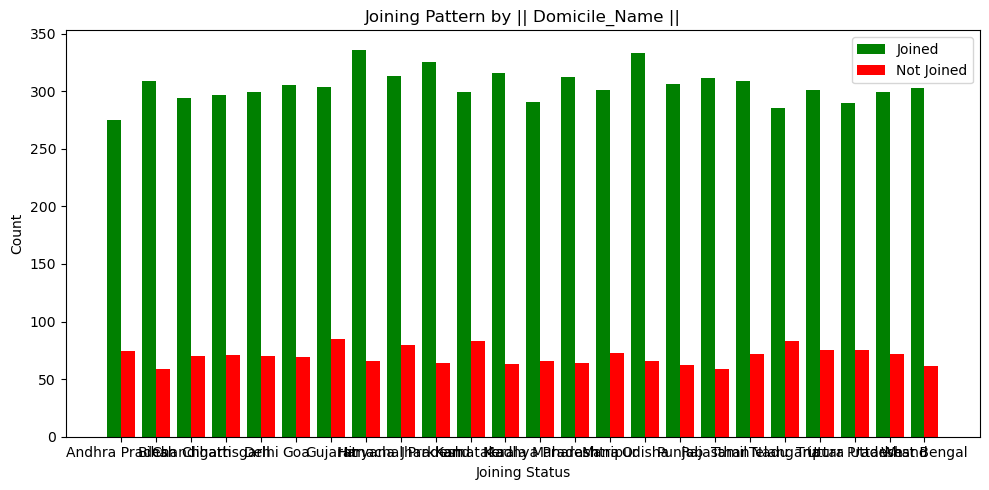

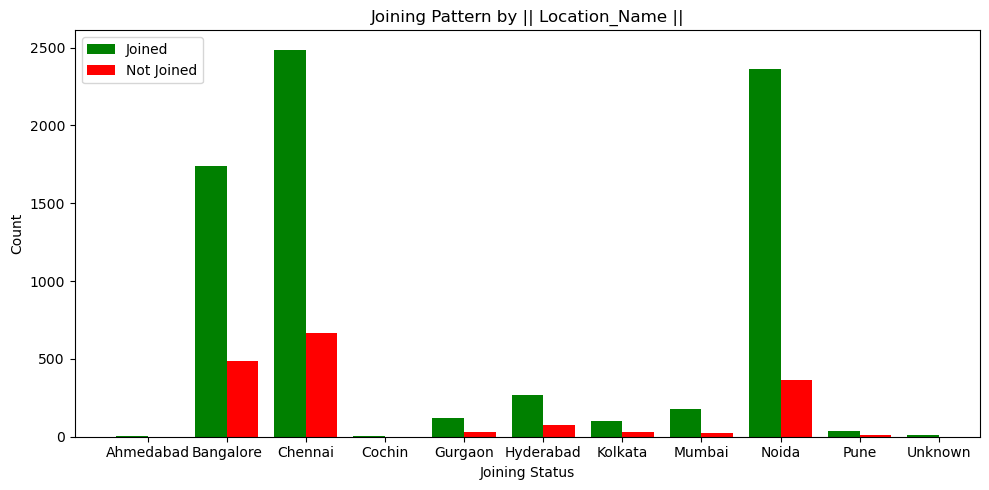

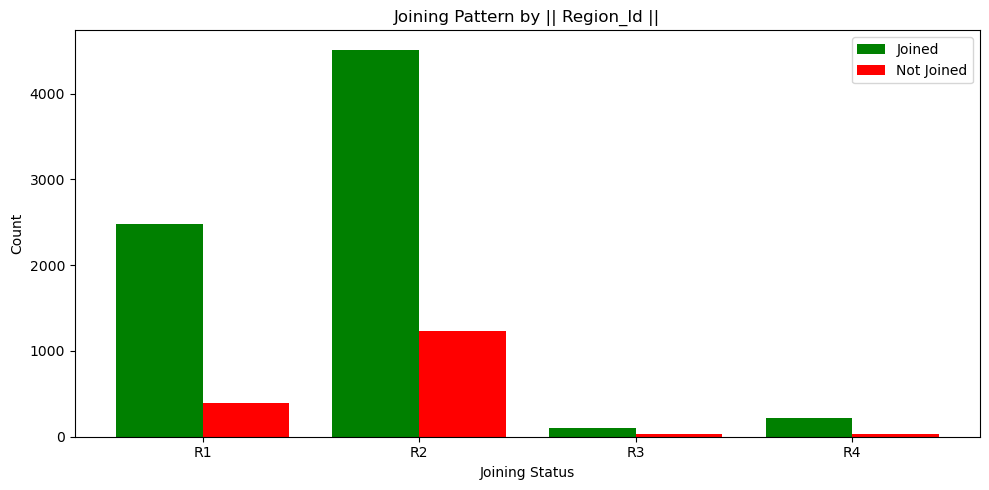

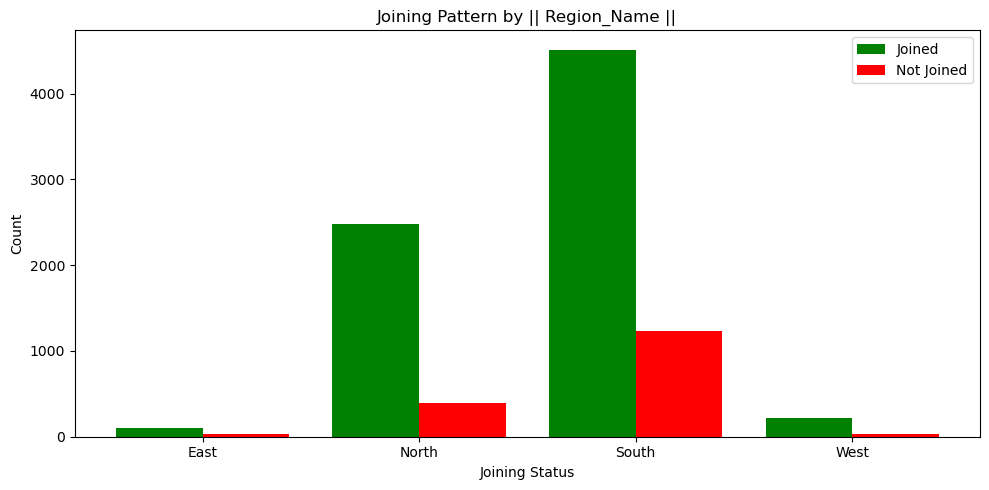

In [77]:
for col in useful_features_categorical:

    result_category = df.groupby([col, 'Status']).size().unstack()

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(result_category.index))
    width = 0.4

    ax.bar(x - width/2, result_category['Joined'], width, label='Joined', color='green')
    ax.bar(x + width/2, result_category['Not Joined'], width, label='Not Joined', color='red')

    ax.set_title(f'Joining Pattern by || {col} ||')
    ax.set_xticks(x)
    ax.set_xticklabels(result_category.index)
    ax.set_xlabel("Joining Status")
    ax.set_ylabel('Count')
    ax.legend()

    plt.tight_layout()
    plt.show()

# Answer - 

## High Impact Drivers

1. Candidate_relocate_actual — Very few candidates who are not offered rellocation haven't joined the company.

3. Notice_Period — higher the notice period lower the joining chances.

5. CTC_diff_pct — if ctc is offered less chances of dropout for candidate is more

7. Candidate_Source — referrals convert significantly better but direct joining is in highest number of joining 

9. Offered_Band — higher band = higher join rate


## Low Impact Drivers

1. LOB — INFRA has the highest number of joining

3. Region_Name — South has most number of joining candidates

5. DOJ_Extended — slight influence

7. Gender — males joining more than females

9. Joining_Bonus — negligible difference

10. Domicile_Name / Domicile_Id — very uniform across states

12. Location_ID — slight impact

14. Expected_CTC_hike_pct — almost identical in both the cases